In [27]:
# ==========================================
# 📦 1. IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             precision_recall_curve)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier

import joblib

!pip install imbalanced-learn shap
from imblearn.over_sampling import SMOTE
import shap


In [28]:
# ==========================================
# 📊 2. LOAD DATA
# ==========================================

df = pd.read_csv('Default_Fin.csv')

# Fix column names
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('?', '')

print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())


   Index  Employed  Bank_Balance  Annual_Salary  Defaulted
0      1         1       8754.36      532339.56          0
1      2         0       9806.16      145273.56          0
2      3         1      12882.60      381205.68          0
3      4         1       6351.00      428453.88          0
4      5         1       9427.92      461562.00          0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Index          10000 non-null  int64  
 1   Employed       10000 non-null  int64  
 2   Bank_Balance   10000 non-null  float64
 3   Annual_Salary  10000 non-null  float64
 4   Defaulted      10000 non-null  int64  
dtypes: float64(2), int64(3)
memory usage: 390.8 KB
None
             Index      Employed  Bank_Balance  Annual_Salary     Defaulted
count  10000.00000  10000.000000  10000.000000   10000.000000  10000.000000
mean    5000.50000    

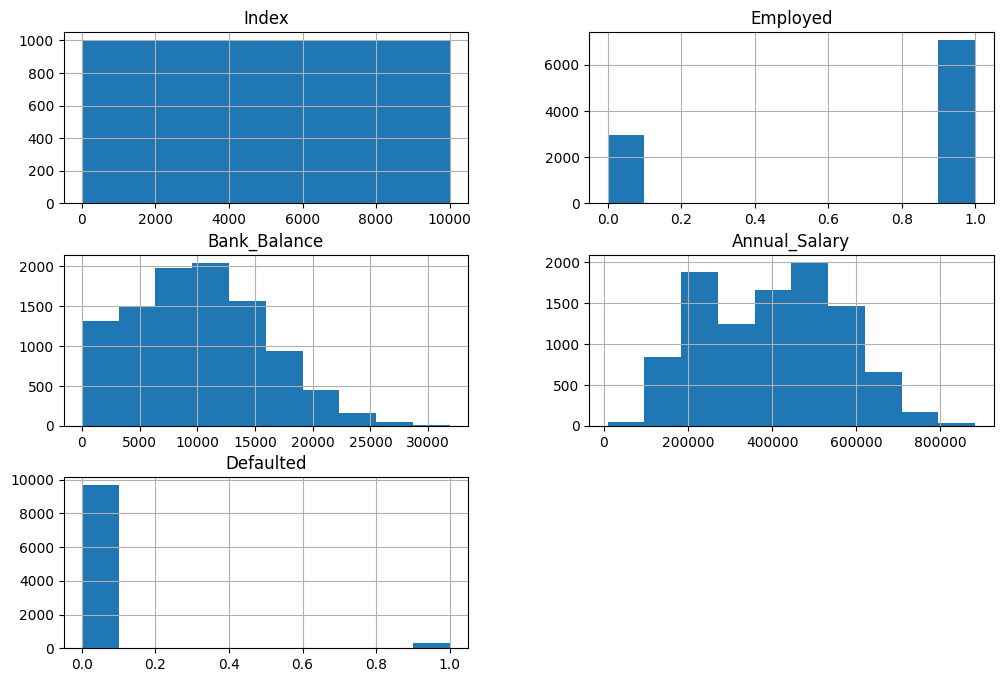

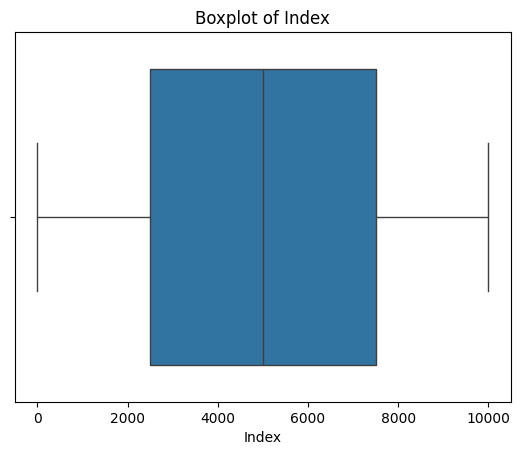

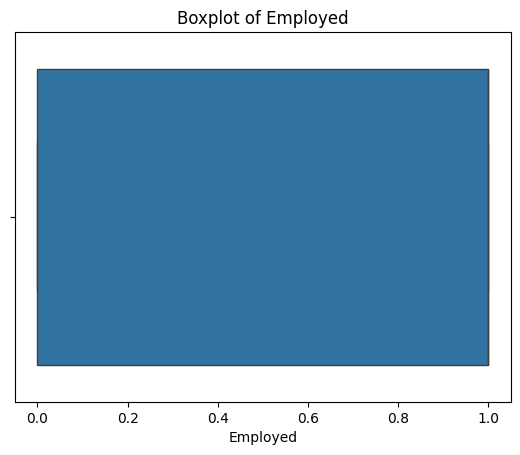

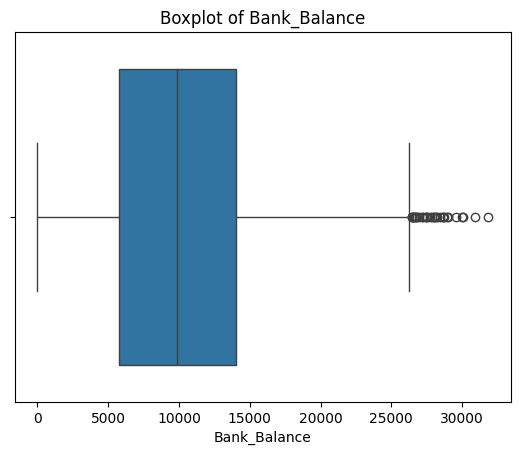

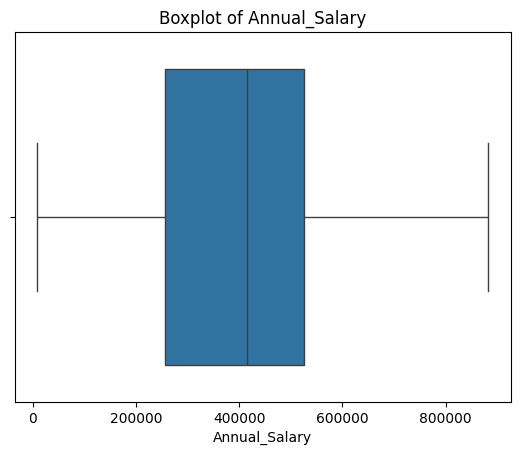

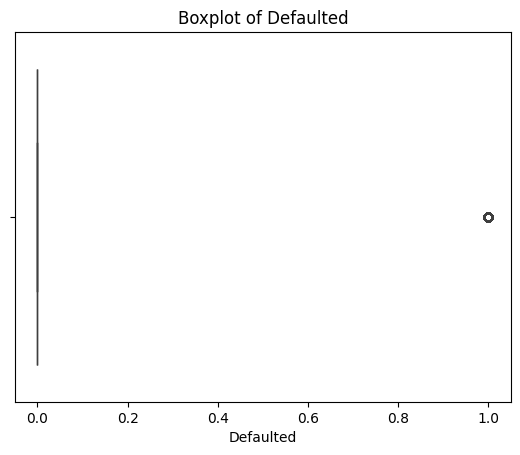

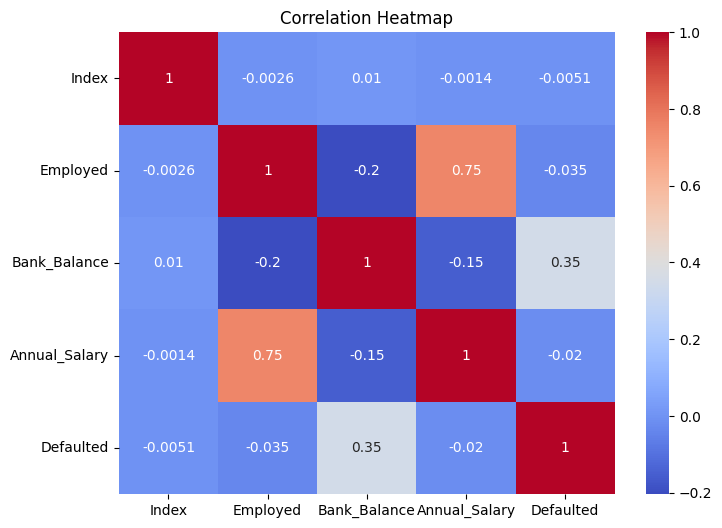

In [29]:
# ==========================================
# 📈 3. DATA AUDIT (EDA)
# ==========================================

df.hist(figsize=(12,8))
plt.show()

for col in df.select_dtypes(include=['int64','float64']):
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


In [30]:
# ==========================================
# 🧹 4. DATA CLEANING
# ==========================================

# Drop unnecessary column
df.drop('Index', axis=1, inplace=True)


In [31]:
# ==========================================
# 🔥 5. OUTLIER HANDLING (IQR)
# ==========================================

def handle_outliers(df):
    for col in ['Bank_Balance', 'Annual_Salary']:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        df[col] = np.where(df[col] > upper, upper,
                  np.where(df[col] < lower, lower, df[col]))
    return df

df = handle_outliers(df)


In [32]:
# ==========================================
# 💎 6. FEATURE ENGINEERING
# ==========================================

df['debt_income_ratio'] = df['Bank_Balance'] / (df['Annual_Salary'] + 1)


In [33]:
# ==========================================
# 🎯 7. DEFINE TARGET
# ==========================================

X = df.drop('Defaulted', axis=1)
y = df['Defaulted']


In [34]:
# ==========================================
# ⚖️ 8. STRATIFIED SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [35]:
# ==========================================
# ⚖️ 9. HANDLE IMBALANCE (SMOTE)
# ==========================================

smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


In [36]:
# ==========================================
# 📏 10. SCALING
# ==========================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [37]:
# ==========================================
# 🤖 11. TRAIN MODELS
# ==========================================

models = {
    "Logistic Regression": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier(),
    "Gradient Boosting": GradientBoostingClassifier()
}

predictions = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    predictions[name] = model.predict(X_test)



===== Logistic Regression =====
Accuracy: 0.869
Precision: 0.18446601941747573
Recall: 0.8507462686567164
F1 Score: 0.30319148936170215
ROC-AUC: 0.8601894819745041


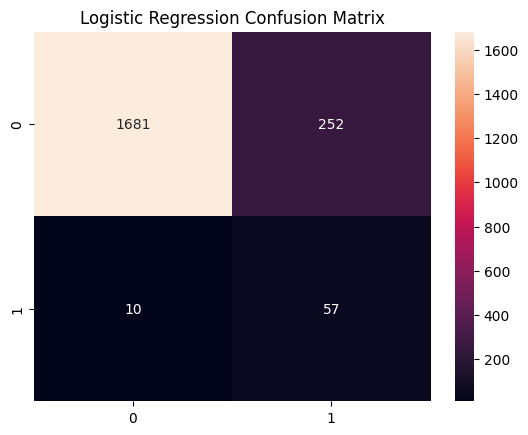


===== Decision Tree =====
Accuracy: 0.9055
Precision: 0.2175925925925926
Recall: 0.7014925373134329
F1 Score: 0.3321554770318021
ROC-AUC: 0.8070318351336951


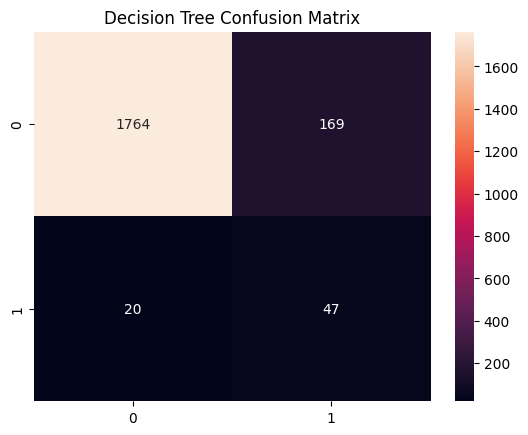


===== Random Forest =====
Accuracy: 0.903
Precision: 0.22510822510822512
Recall: 0.7761194029850746
F1 Score: 0.348993288590604
ROC-AUC: 0.8417586150983314


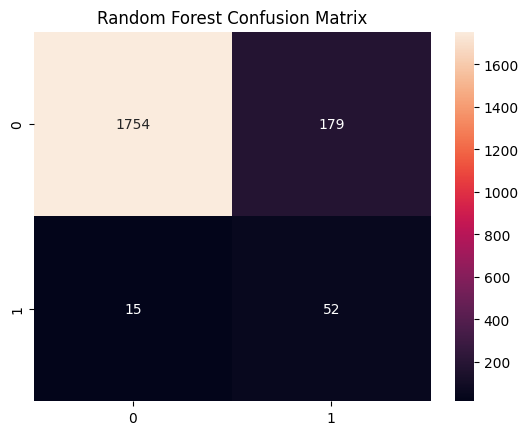


===== KNN =====
Accuracy: 0.8815
Precision: 0.19642857142857142
Recall: 0.8208955223880597
F1 Score: 0.3170028818443804
ROC-AUC: 0.8522480715923744


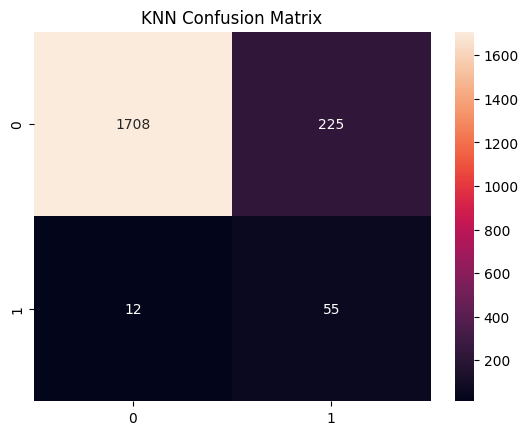


===== Gradient Boosting =====
Accuracy: 0.866
Precision: 0.17891373801916932
Recall: 0.835820895522388
F1 Score: 0.29473684210526313
ROC-AUC: 0.8514334689717475


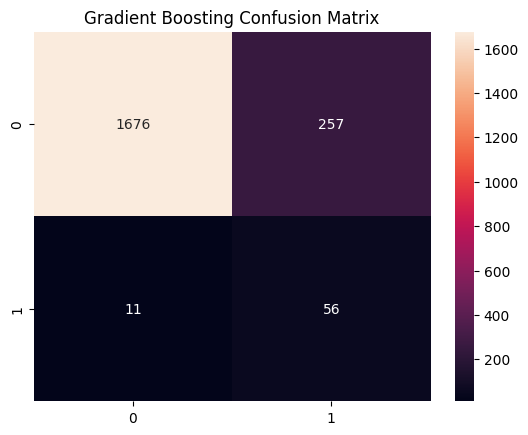

In [38]:
# ==========================================
# 📊 12. EVALUATION FUNCTION
# ==========================================

def evaluate_model(y_test, pred, name):
    print(f"\n===== {name} =====")
    print("Accuracy:", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall:", recall_score(y_test, pred))
    print("F1 Score:", f1_score(y_test, pred))
    print("ROC-AUC:", roc_auc_score(y_test, pred))

    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d')
    plt.title(f"{name} Confusion Matrix")
    plt.show()

for name, pred in predictions.items():
    evaluate_model(y_test, pred, name)


In [39]:
# ==========================================
# ⚡ 13. HYPERPARAMETER TUNING (RF)
# ==========================================

param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None]
}

grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=3, scoring='f1')
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_


In [40]:
# ==========================================
# ⚡ 14. TUNE GRADIENT BOOSTING
# ==========================================

param_grid_gb = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid_gb = GridSearchCV(GradientBoostingClassifier(), param_grid_gb, cv=3, scoring='f1')
grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_


In [41]:
# ==========================================
# 🎯 15. THRESHOLD OPTIMIZATION
# ==========================================

y_probs = best_rf.predict_proba(X_test)[:,1]

precision, recall, thresholds = precision_recall_curve(y_test, y_probs)

best_threshold = thresholds[np.argmax(recall)]
print("Best Threshold:", best_threshold)

y_pred_custom = (y_probs >= best_threshold).astype(int)


Best Threshold: 0.0



===== Tuned RF with Optimized Threshold =====
Accuracy: 0.0335
Precision: 0.0335
Recall: 1.0
F1 Score: 0.0648282535074988
ROC-AUC: 0.5


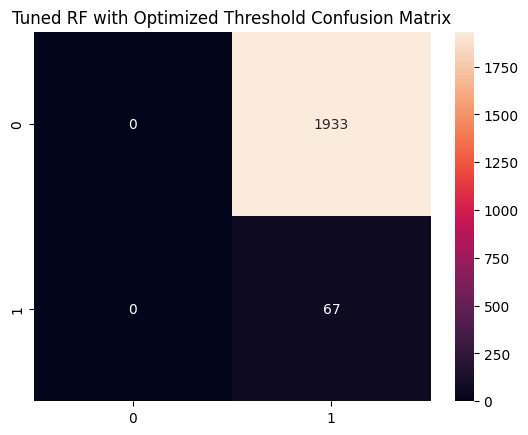

In [42]:
# ==========================================
# 📊 16. FINAL EVALUATION
# ==========================================

evaluate_model(y_test, y_pred_custom, "Tuned RF with Optimized Threshold")


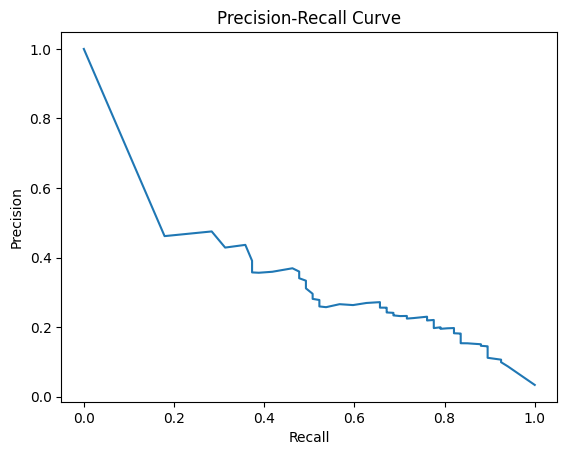

In [43]:
# ==========================================
# 📈 17. PRECISION-RECALL CURVE
# ==========================================

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()


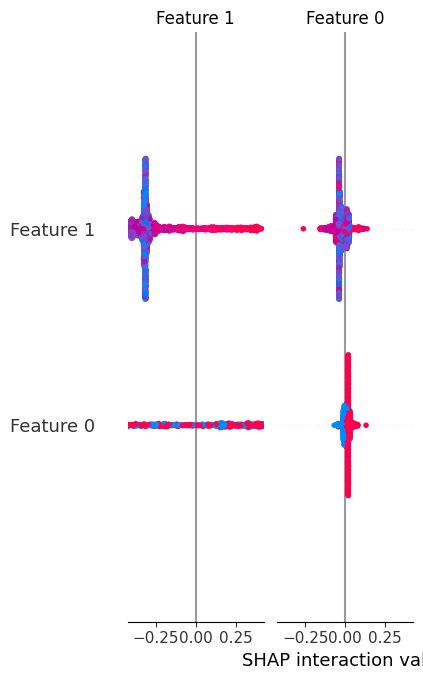

In [44]:
# ==========================================
# 🧬 18. SHAP EXPLAINABILITY
# ==========================================

explainer = shap.Explainer(best_rf)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)


In [45]:
# ==========================================
# 💾 19. SAVE MODEL
# ==========================================

joblib.dump(best_rf, 'loan_model.pkl')


['loan_model.pkl']

In [46]:
# ==========================================
# 💰 20. RISK FUNCTION
# ==========================================

def risk_level(pred):
    return "High Risk" if pred == 1 else "Low Risk"

print(risk_level(y_pred_custom[0]))


High Risk
